In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def to_pixel_arrays(my_df, activation_threshold=0, x_dimension=16, y_dimension=16):
    pixel_arrays_flat = my_df.to_numpy() 
    num_activated_pixels = np.sum((pixel_arrays_flat > activation_threshold), axis=1)
    pixel_arrays = pixel_arrays_flat.reshape(-1, y_dimension, x_dimension) 
    x_sizes = np.sum(np.any(pixel_arrays > activation_threshold, axis=1), axis=1) 
    y_sizes = np.sum(np.any(pixel_arrays > activation_threshold, axis=2), axis=1)
    
    return pixel_arrays_flat, pixel_arrays, num_activated_pixels, x_sizes, y_sizes

In [3]:
train_df = pd.read_parquet(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_-8_8_offsets_parquets/train_contained/*.parquet'))
test_df = pd.read_parquet(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_-8_8_offsets_parquets/test_contained/*.parquet'))
df = pd.concat([train_df, test_df], ignore_index=True)

In [4]:
print(f'Total number of events: {len(df)}')
print(f'Number of training events: {len(train_df)}')
print(f'Number of validation events: {len(test_df)}')

Total number of events: 591560
Number of training events: 473233
Number of validation events: 118327


In [5]:
train_df

,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,pt,cotAlpha,...,5110,5111,5112,5113,5114,5115,5116,5117,5118,5119
0,-112.062332,-44.947617,100.0,4.174749,1.421584,-1.164173,32916.0,35.490101,-1.837450,-3.586021,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-16.144743,8.468513,100.0,2.974582,0.210798,-1.940088,15497.0,3.131100,-1.951500,-1.533220,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-150.194824,54.753010,100.0,4.620924,-1.225346,-1.466355,27969.0,-26.332399,-1.910930,-3.151300,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-282.535706,55.151821,100.0,13.660900,-1.506860,-2.712126,42960.0,-16.579901,-3.102610,-5.036971,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-281.475952,-1.228071,100.0,5.027569,0.081731,-0.873842,44599.0,3.215600,0.877655,-5.753407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432411,198.792664,26.867180,100.0,-14.937030,-1.892758,-4.304148,32699.0,-13.123200,-4.701950,3.470380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
432412,160.424393,44.587395,100.0,-4.370597,-0.915748,-1.391857,41347.0,-19.087700,1.666090,3.140119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
432413,-225.101212,-48.946190,100.0,3.460599,0.666205,-0.638635,43725.0,29.877501,-0.922869,-5.418743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
432414,-167.833237,-35.764320,100.0,11.507595,2.392200,-3.451474,30039.0,20.588100,-4.199420,-3.334110,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
test_df

,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,pt,cotAlpha,...,5110,5111,5112,5113,5114,5115,5116,5117,5118,5119
0,371.131714,-29.986162,100.0,-25.288870,3.219761,-3.764059,52308.0,24.601000,-4.95329,6.718511,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,143.264175,-41.651131,100.0,-8.524582,2.833035,-2.270769,28995.0,37.911900,3.63077,3.754051,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-41.900448,31.115921,100.0,0.218069,-0.881706,-1.792341,6068.0,-15.826600,-1.99747,-0.121667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,86.395554,1.966478,100.0,1.793251,0.627153,-4.676721,9347.0,3.797840,4.71859,-0.383442,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-34.047733,3.808246,100.0,4.619514,-0.519359,-4.500125,16109.0,-2.864780,4.53000,-1.026530,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108217,-180.671387,-49.566227,100.0,8.537430,2.629498,-1.873262,30199.0,40.783100,-3.22852,-4.557521,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108218,-63.300816,7.760604,100.0,0.274150,0.015233,-0.114793,19611.0,-0.111518,-0.11580,-2.388212,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108219,42.833809,-14.089409,100.0,-4.019694,1.522840,-1.956684,18269.0,23.473700,-2.47944,2.054340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108220,91.538689,4.213895,100.0,-4.125282,1.078161,-2.873840,13584.0,11.260500,-3.06943,1.435460,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


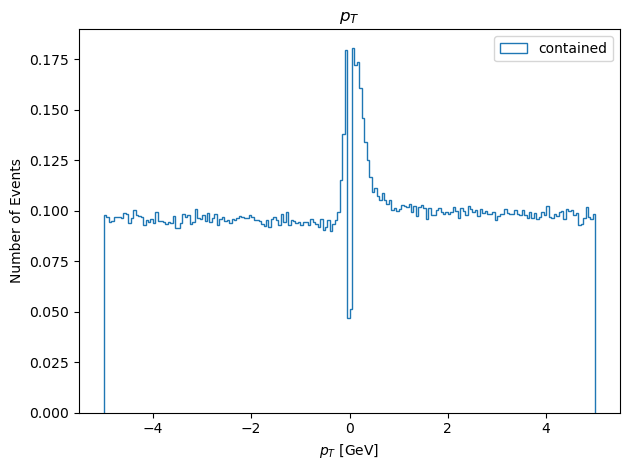

In [8]:
fig, ax = plt.subplots()

ax.hist(df['pt'], bins=200, histtype='step', density=True, label='contained')
ax.legend()
ax.set_title(r'$p_T$')
ax.set_xlabel(r'$p_T$ [GeV]')
ax.set_ylabel(r'Number of Events')
fig.tight_layout()
fig.show()

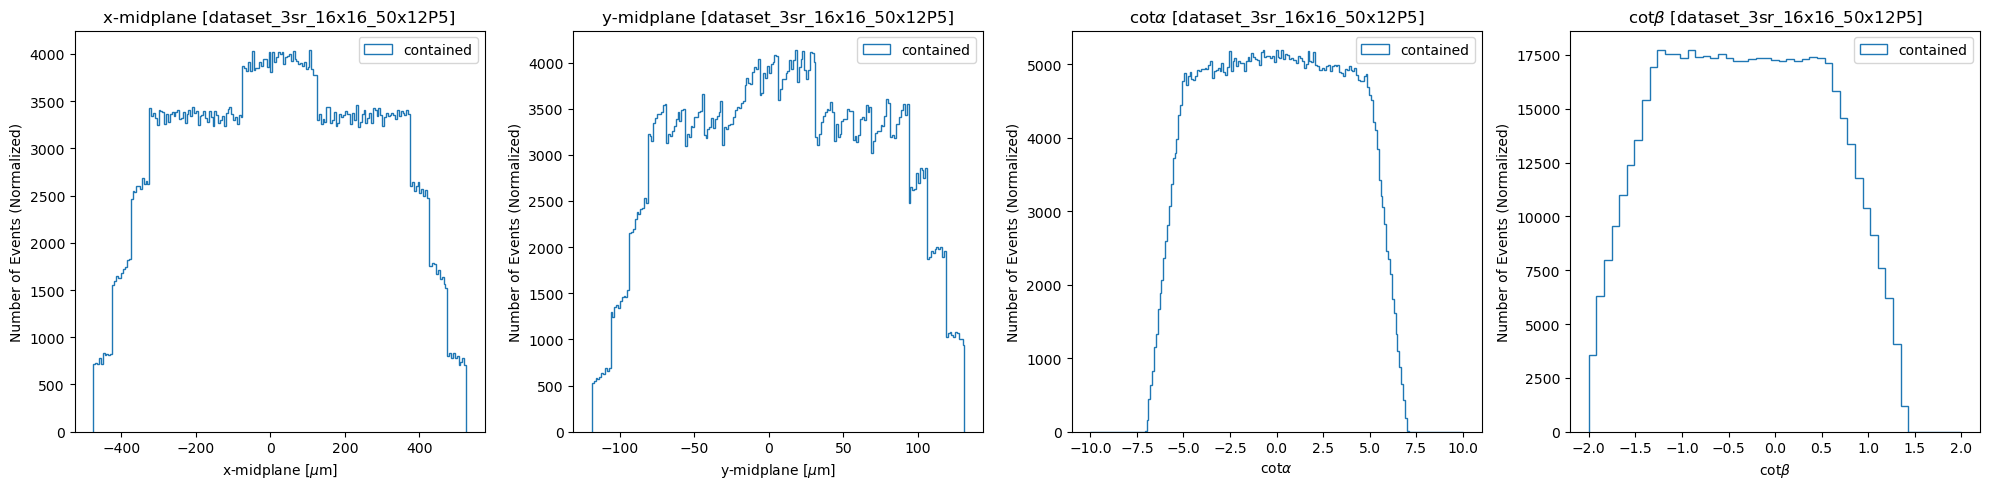

In [5]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].hist(df['x-midplane'], bins=200, histtype='step', label='contained')
ax[0].set_title(r'x-midplane [dataset_3sr_16x16_50x12P5]')
ax[0].set_xlabel(r'x-midplane [$\mu$m]')
ax[0].set_ylabel(r'Number of Events (Normalized)')
ax[0].legend()

ax[1].hist(df['y-midplane'], bins=200, histtype='step', label='contained')
ax[1].set_title(r'y-midplane [dataset_3sr_16x16_50x12P5]')
ax[1].set_xlabel(r'y-midplane [$\mu$m]')
ax[1].set_ylabel(r'Number of Events (Normalized)')
ax[1].legend()

ax[2].hist(df['cotAlpha'], bins=np.linspace(-10,10,200), histtype='step', label='contained')
ax[2].set_title(r'cot$\alpha$ [dataset_3sr_16x16_50x12P5]')
ax[2].set_xlabel(r'cot$\alpha$')
ax[2].set_ylabel(r'Number of Events (Normalized)')
ax[2].legend()

ax[3].hist(df['cotBeta'], bins=np.linspace(-2,2), histtype='step', label='contained')
ax[3].set_title(r'cot$\beta$ [dataset_3sr_16x16_50x12P5]')
ax[3].set_xlabel(r'cot$\beta$')
ax[3].set_ylabel(r'Number of Events (Normalized)')
ax[3].legend()

fig.tight_layout()
fig.show()

/tmp/ipykernel_3408968/2015290544.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


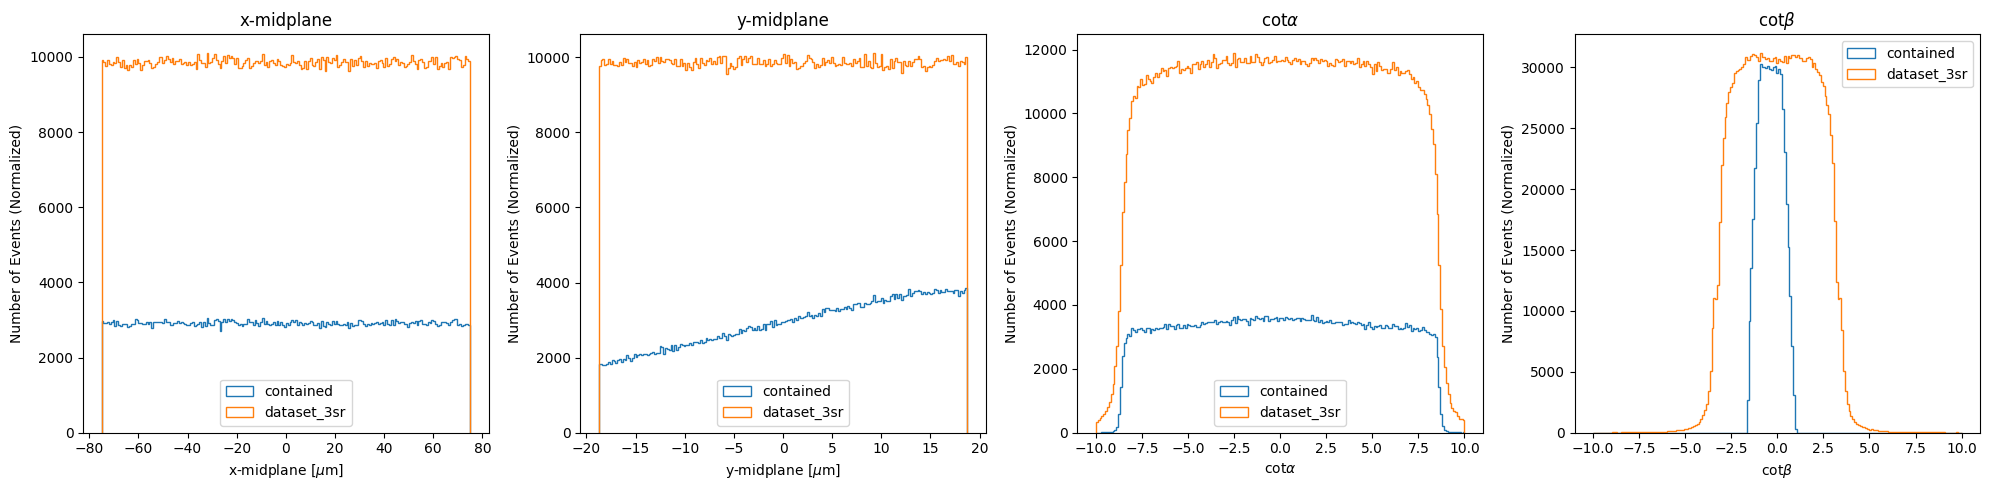

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].hist(df['x-midplane'], bins=200, histtype='step', label='contained')
ax[0].set_title(r'x-midplane')
ax[0].set_xlabel(r'x-midplane [$\mu$m]')
ax[0].set_ylabel(r'Number of Events (Normalized)')
ax[0].legend()

ax[1].hist(df['y-midplane'], bins=200, histtype='step', label='contained')
ax[1].set_title(r'y-midplane')
ax[1].set_xlabel(r'y-midplane [$\mu$m]')
ax[1].set_ylabel(r'Number of Events (Normalized)')
ax[1].legend()

ax[2].hist(df['cotAlpha'], bins=np.linspace(-10,10,200), histtype='step', label='contained')
ax[2].set_title(r'cot$\alpha$')
ax[2].set_xlabel(r'cot$\alpha$')
ax[2].set_ylabel(r'Number of Events (Normalized)')
ax[2].legend()

ax[3].hist(df['cotBeta'], bins=np.linspace(-10,10,200), histtype='step', label='contained')
ax[3].set_title(r'cot$\beta$')
ax[3].set_xlabel(r'cot$\beta$')
ax[3].set_ylabel(r'Number of Events (Normalized)')
ax[3].legend()

fig.tight_layout()
fig.savefig('plots/dataset_3sr_16x16_contained_plots/labels_vs_default.png', dpi=300)
fig.show()

In [ ]:
final_timeslice_df = df.iloc[:,-256:]
final_timeslice_df

,4864,4865,4866,4867,4868,4869,4870,4871,4872,4873,...,5110,5111,5112,5113,5114,5115,5116,5117,5118,5119
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
521488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
521489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
521490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
pixel_arrays_flat, pixel_arrays, num_activated_pixels, x_sizes, y_sizes = to_pixel_arrays(final_timeslice_df, 400, x_dimension=16, y_dimension=16)

/tmp/ipykernel_1069546/3656880118.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


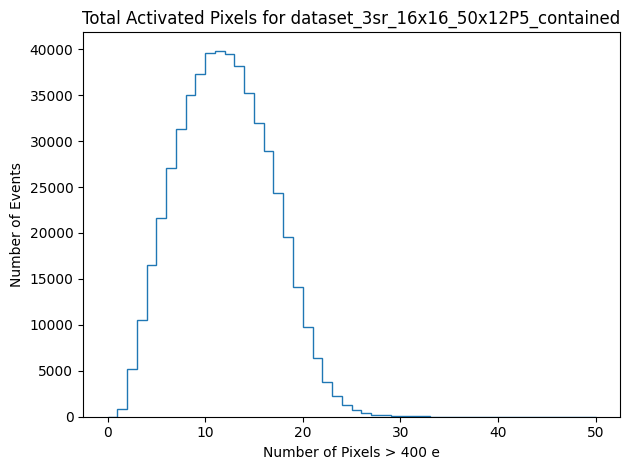

In [ ]:
fig, ax = plt.subplots()

ax.hist(num_activated_pixels, bins=np.linspace(0,50,51), histtype='step')
ax.set_xlabel('Number of Pixels > 400 e')
ax.set_ylabel('Number of Events')
ax.set_title('Total Activated Pixels for dataset_3sr_16x16_50x12P5_contained')
fig.tight_layout()
fig.savefig('plots/dataset_3sr_16x16_contained_plots/num_activated_pixels.png', dpi=300)
fig.show()

/tmp/ipykernel_1069546/2480187811.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


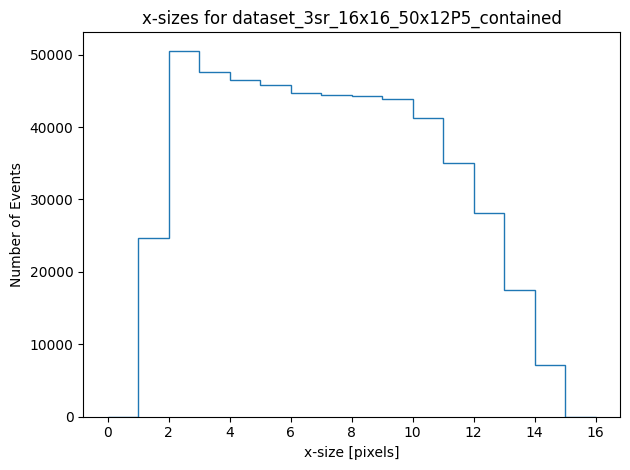

In [ ]:
fig, ax = plt.subplots()

ax.hist(x_sizes, bins=np.linspace(0,16,17), histtype='step')
ax.set_xlabel('x-size [pixels]')
ax.set_ylabel('Number of Events')
ax.set_title('x-sizes for dataset_3sr_16x16_50x12P5_contained')
fig.tight_layout()
fig.savefig('plots/dataset_3sr_16x16_contained_plots/x_size.png', dpi=300)
fig.show()

/tmp/ipykernel_1069546/4172680249.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


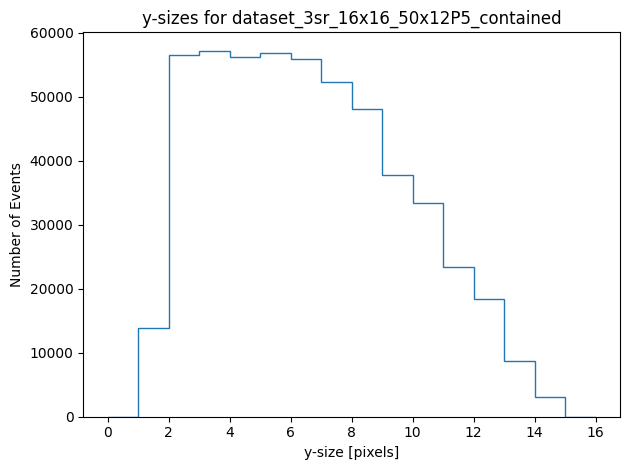

In [ ]:
fig, ax = plt.subplots()

ax.hist(y_sizes, bins=np.linspace(0,16,17), histtype='step')
ax.set_xlabel('y-size [pixels]')
ax.set_ylabel('Number of Events')
ax.set_title('y-sizes for dataset_3sr_16x16_50x12P5_contained')
fig.tight_layout()
fig.savefig('plots/dataset_3sr_16x16_contained_plots/y_size.png', dpi=300)
fig.show()

In [ ]:
# Get the maximum and minimum charge for each event
pixel_arrays_inclusive = pixel_arrays_flat
pixel_arrays_flat[pixel_arrays_flat <= 400] = np.nan
max_charge = np.nanmax(pixel_arrays_flat, axis=1)
min_charge = np.nanmin(pixel_arrays_flat, axis=1)
mean_charge = np.nanmean(pixel_arrays_flat, axis=1)
median_charge = np.nanmedian(pixel_arrays_flat, axis=1)


/tmp/ipykernel_1069546/4114286789.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


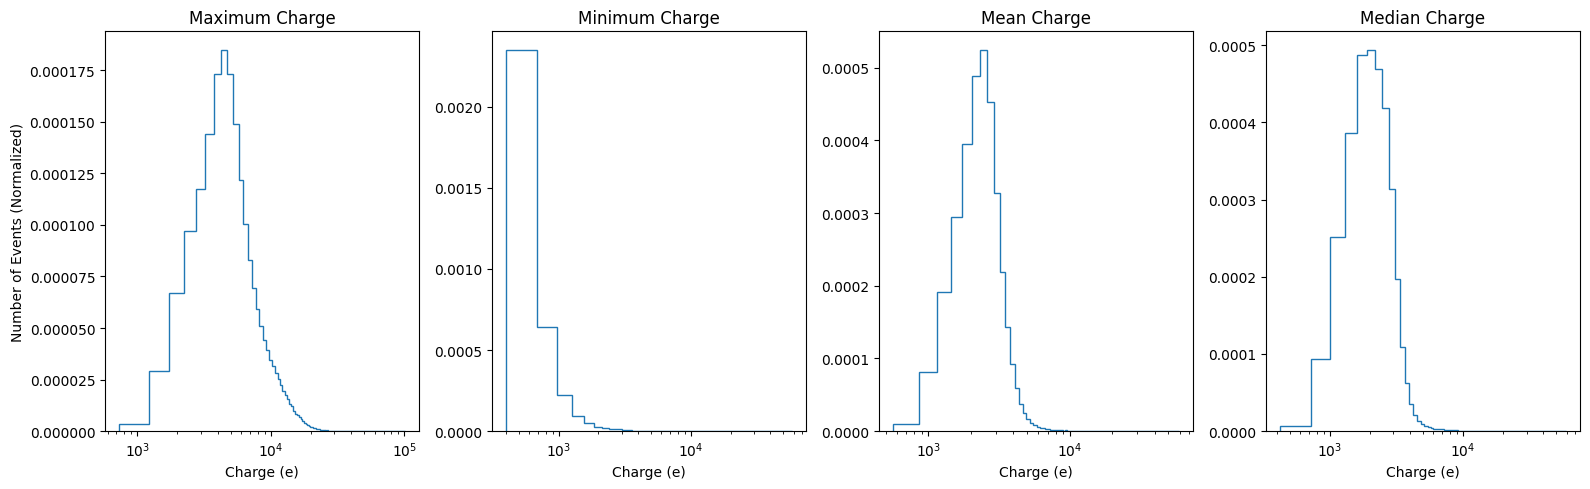

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(16,5))
ax[0].hist(max_charge, histtype='step', bins=200, density=True)
ax[0].set_xscale('log')
ax[0].set_xlabel('Charge (e)')
ax[0].set_ylabel('Number of Events (Normalized)')
ax[0].set_title('Maximum Charge')

ax[1].hist(min_charge, histtype='step', bins=200, density=True)
ax[1].set_xscale('log')
ax[1].set_xlabel('Charge (e)')
#ax[1].set_ylabel('Number of Events')
ax[1].set_title('Minimum Charge')

ax[2].hist(mean_charge, histtype='step', bins=200, density=True)
ax[2].set_xscale('log')
ax[2].set_xlabel('Charge (e)')
#ax[2].set_ylabel('Number of Events')
ax[2].set_title('Mean Charge')

ax[3].hist(median_charge, histtype='step', bins=200, density=True)
ax[3].set_xscale('log')
ax[3].set_xlabel('Charge (e)')
#ax[3].set_ylabel('Number of Events')
ax[3].set_title('Median Charge')

fig.tight_layout()
fig.show()

/tmp/ipykernel_1069546/4117246589.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Maximum charge --> minimum = 735.0, maximum = 100770.0
Minimum charge --> minimum = 401.0, maximum = 58171.0
Mean charge --> minimum = 567.0, maximum = 59115.0
Median charge --> minimum = 424.0, maximum = 59115.0


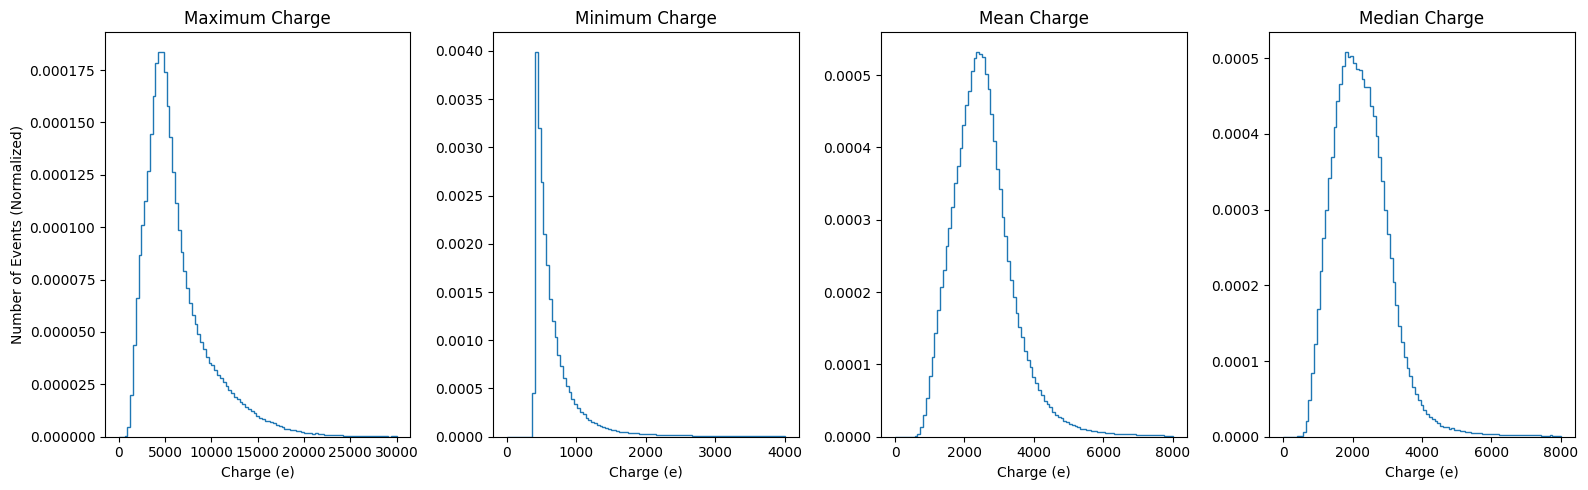

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(16,5))
ax[0].hist(max_charge, histtype='step', bins=np.linspace(0,30000,100), density=True)
ax[0].set_xlabel('Charge (e)')
ax[0].set_ylabel('Number of Events (Normalized)')
ax[0].set_title('Maximum Charge')

ax[1].hist(min_charge, histtype='step', bins=np.linspace(0,4000,100), density=True)
ax[1].set_xlabel('Charge (e)')
ax[1].set_title('Minimum Charge')

ax[2].hist(mean_charge, histtype='step', bins=np.linspace(0,8000,100), density=True)
ax[2].set_xlabel('Charge (e)')
ax[2].set_title('Mean Charge')

ax[3].hist(median_charge, histtype='step', bins=np.linspace(0,8000,100), density=True)
ax[3].set_xlabel('Charge (e)')
ax[3].set_title('Median Charge')

fig.tight_layout()
fig.show()
print(f'Maximum charge --> minimum = {np.nanmin(max_charge)}, maximum = {np.nanmax(max_charge)}')
print(f'Minimum charge --> minimum = {np.nanmin(min_charge)}, maximum = {np.nanmax(min_charge)}')
print(f'Mean charge --> minimum = {np.nanmin(mean_charge)}, maximum = {np.nanmax(mean_charge)}')
print(f'Median charge --> minimum = {np.nanmin(median_charge)}, maximum = {np.nanmax(median_charge)}')